In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torchvision
from transformers import CLIPProcessor, CLIPTextModelWithProjection
import torch.optim as optim
import pickle
from diffusers import AutoencoderKL
from tqdm import tqdm
import matplotlib.pyplot as plt

/home/rianbutala/projects/sd-v5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("jackyhate/text-to-image-2M", streaming=True)
print(next(iter(ds['train']))['json']['prompt'])
print(next(iter(ds['train']))['jpg'])

A promotional image for a crampon storage bag with a group of hikers in the background. The bag is prominently displayed in the foreground, with a large, detailed image of the bag's mesh design and a smaller image of the bag's orange and blue color scheme. The text 'CRAMPON STORAGE BAG' is displayed at the top, along with the tagline 'Premium Material, Practical Design, Easy to Use'. The background features a snowy mountain landscape with hikers in various colors of jackets and backpacks.
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x1024 at 0x701B8161D310>


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transforms = torchvision.transforms.Compose([
  torchvision.transforms.Resize((256, 256)),
  torchvision.transforms.ToTensor()
])

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model_id="openai/clip-vit-base-patch32"
clip_model = CLIPTextModelWithProjection.from_pretrained(model_id).to(device).eval()

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").eval().to(device)

def embed_text(text):
  # inputs = tokenizer([text], return_tensors="pt")
  inputs =processor(text=text, return_tensors="pt", padding=True, truncation=True, max_length=77).to(device)
  # print(type(inputs))
  with torch.inference_mode():
    # outputs = clip_model(**inputs)    
    outputs =clip_model(**inputs)
  embeds=outputs.text_embeds
  # chunks = torch.chunk(embeds, chunks=2, dim=2)# tuple: B,1,256 each
  # embeds = torch.cat(chunks, dim=1) # B,2,256
  # print(f"emb 1: {embeds.shape}")
  return embeds # returns a 1,512

class TextImageDataset(Dataset):
    def __init__(self, dataset, transforms=None):
        self.dataset = dataset
        self.transforms = transforms
        self.dataset_iter = iter(self.dataset)

    def __len__(self):
        return int(1e10)

    def __getitem__(self, idx):
        try:
          item = next(self.dataset_iter)
        except StopIteration:
          self.dataset_iter = iter(self.dataset)
          item = next(self.dataset_iter)
        image = item['jpg'] # PIL image
        prompt = item['json']['prompt'] # text
        prompt = embed_text(prompt).squeeze(0) #1,512 -> 512, because dataloader wraps 1, anwyays
        # print(prompt.shape)
        image = transforms(image) if self.transforms else image
        # image = vae.encode(image.to(device).unsqueeze(0)).latent_dist.sample()*vae.config.scaling_factor
        # print(image.shape)
        return image, prompt

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 55679.10it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder

In [4]:
ds_obj = TextImageDataset(ds['train'], transforms=transforms)
dataloader = DataLoader(ds_obj, batch_size=1)
# next(iter(dataloader))[0]

In [5]:
total_entries = 262144# MUST BE DIVISIBLE BY BATCH SIZE
batch_size=128

dl_iter = iter(dataloader)

populate_pickle =True
test_pickle=False

if populate_pickle:
  with open("data/tensors.pkl", "wb") as f:
    pickler = pickle.Pickler(f, protocol=pickle.HIGHEST_PROTOCOL)
    for i in tqdm(range(total_entries)):
      next_obj = next(dl_iter)
      image = next_obj[0].to(device)
      # print(f"image shape {image.shape}")
      image = image*2-1 # MUST RUN /2 + 0.5 .CLAMP (0,1)
      image = vae.encode(image.to(device)).latent_dist.sample()*vae.config.scaling_factor
      # store on CPU: forked DataLoader workers can't deserialize CUDA tensors
      next_obj[0] = image.cpu()
      next_obj[1] = next_obj[1].cpu()
      pickler.dump(next_obj)
      pickler.clear_memo()

def load_stream(path="data/tensors.pkl"):
    with open(path, "rb") as f:
        while True:
            try:
                # yield unpickler.load()
                yield pickle.Unpickler(f).load()
            except EOFError:
                break

if test_pickle:
  for i in tqdm(load_stream(), total=total_entries):
    pass

print(next(iter(load_stream()))[0].shape)

100%|██████████| 262144/262144 [1:06:47<00:00, 65.41it/s]

torch.Size([1, 4, 32, 32])


In [6]:
# ONE-TIME: existing tensors.pkl holds CUDA tensors, which forked DataLoader
# workers can't deserialize. Rewrite it with CPU tensors (runs in main process
# where CUDA is initialized). Safe to delete this cell after it runs once.
import os
convert_to_cpu = True

if convert_to_cpu:
  src, tmp = "data/tensors.pkl", "data/tensors.cpu.tmp"
  with open(tmp, "wb") as f:
    p = pickle.Pickler(f, protocol=pickle.HIGHEST_PROTOCOL)
    for img, prompt in tqdm(load_stream(src), total=total_entries):
      p.dump((img.cpu(), prompt.cpu()))
      p.clear_memo()
  os.replace(tmp, src)
  if os.path.exists("data/offsets.pt"):
    os.remove("data/offsets.pt")   # byte offsets are now stale -> force rebuild


100%|██████████| 262144/262144 [00:32<00:00, 8116.39it/s]


In [7]:
import os

def build_index(path="data/tensors.pkl", index="data/offsets.pt"):
  # scan the pickle ONCE, record the byte offset of every record
  if os.path.exists(index):
    return torch.load(index)
  offsets = []
  with open(path, "rb") as f:
    while True:
      pos = f.tell()
      try:
        pickle.Unpickler(f).load()   # advances f past one record
      except EOFError:
        break
      offsets.append(pos)
  torch.save(offsets, index)
  return offsets

class PickledImageTextDataset(Dataset):
  def __init__(self, path="data/tensors.pkl"):
    self.path = path
    self.offsets = build_index(path)
    self.f = None                      # opened lazily, once per worker

  def __len__(self):
    return len(self.offsets)

  def __getitem__(self, idx):
    if self.f is None:
      self.f = open(self.path, "rb")   # each worker gets its own handle
    self.f.seek(self.offsets[idx])
    data = pickle.load(self.f)

    # .detach(): stored latents kept a grad graph from vae.encode(); collate
    # with pin_memory uses torch.stack(out=...) which rejects grad tensors
    image = data[0].squeeze(0).detach()
    prompt = data[1].detach()
    return image, prompt

dataset = PickledImageTextDataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=8, persistent_workers=True,
                        prefetch_factor=4, pin_memory=True)

In [8]:
next(iter(dataloader))[1].shape

torch.Size([128, 1, 512])

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from components.model3 import DiffusionModel

image_tokens=128
model = DiffusionModel(image_tokens=image_tokens,dim=256).to(device)

print(f"{sum([p.numel() for p in model.parameters()])/1_000_000:.1f}m parameters")

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

train_rf = True
save_rf = True

def embed_text(text):
  # inputs = tokenizer([text], return_tensors="pt")
  inputs =processor(text=list(text), return_tensors="pt", padding=True, truncation=True, max_length=77).to(device)
  # print(type(inputs))
  with torch.inference_mode():
    # outputs = clip_model(**inputs)    
    outputs =clip_model(**inputs)
  embeds=outputs.text_embeds.unsqueeze(1) # B,1, 512
  # chunks = torch.chunk(embeds, chunks=2, dim=2)# tuple: B,1,256 each
  # embeds = torch.cat(chunks, dim=1) # B,2,256
  return embeds



cfg_prob=0.1
cfg_prompt=embed_text(['null']).to(device).repeat(batch_size,1,1)
compiled_model = torch.compile(model)
# compiled_model = model
rf_steps = 300000
pbar = tqdm(range(rf_steps))
pd_iter = iter(dataloader)


if train_rf:
  for step in pbar:
      try:
          images, prompts = next(pd_iter)
      except StopIteration:
          pd_iter = iter(dataloader)
          images, prompts = next(pd_iter)

      images = images.to(device) # B,3,256,256
      prompts = prompts.to(device)
      # prompts = prompts.to(device) # B,2,256
      if torch.rand(1) < cfg_prob:
        prompts = cfg_prompt
      # else:
        # prompts=embed_text(prompts)

      t = torch.rand([images.size(0),1,1], device=device) # B,1

      # x1 = compiled_model.encode(images)
      # with torch.no_grad():
        # x1 = vae.encode(images).latent_dist.sample()*vae.config.scaling_factor
        # x1 = images
        # print(f"images shape {images.shape}")
        # x1 = x1.reshape(images.size(0),16,-1)
        # print(f"x1 shape: {x1.shape}")
      with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        x1=images.reshape(images.size(0),image_tokens,-1)
        x0 = torch.randn_like(x1)
        
        # print(f"sanity shape check: x0: {x0.shape}, x1: {x1.shape}, t: {t.shape}")
        x_t = x0*(1-t)+x1*t
        
        predicted_velocity=compiled_model(x_t, prompts, t)
        target_velocity = x1-x0

      loss = F.mse_loss(predicted_velocity, target_velocity)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if step%20 ==0:
        pbar.set_description(f"loss: {loss.item():.4f}")
  if save_rf:
    torch.save(model.state_dict(), "checkpoints/model-v1.pth")
else:
  model.load_state_dict(torch.load("checkpoints/model-v1.pth"))


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 55649.10it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder

67.5m parameters


loss: 0.9063: 100%|██████████| 300000/300000 [47:51<00:00, 104.48it/s]


100%|██████████| 50/50 [00:00<00:00, 407.08it/s]

zshape torch.Size([1, 128, 32])


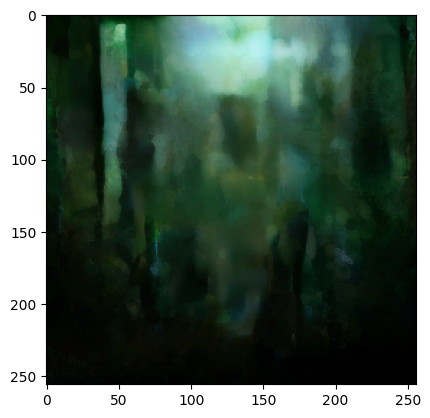

In [69]:
model.eval()
z = torch.randn([1,128,32]).to(device)
steps=50
guidance_scale=2
prompt=(['a dark forest, with tall trees surrounding. photorealistic'])
prompt_emb = embed_text(prompt)
null_prompt = embed_text(['null'])
with torch.no_grad():
  for i in tqdm(range(steps)):
    # t = torch.tensor(i/steps).to(device)
    t = torch.full((z.size(0),1,1), i/steps, device=device)
    v_null_prompt = model(z, null_prompt, t)
    v_pred = model(z, prompt_emb,t)

    v_latent = v_null_prompt + guidance_scale*(v_pred-v_null_prompt)
    z = v_latent*1/steps + z

  print(f"zshape {z.shape}")
  z = z.reshape(1,4,32,32) / vae.config.scaling_factor
  image = (vae.decode(z).sample/2 + 0.5).clamp(0,1)
plt.imshow(image[0].squeeze(0).permute(1,2,0).cpu().detach().numpy())